In [1]:
import brainsss
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import fcluster
from scipy.cluster import hierarchy
from scipy.signal import butter, filtfilt, freqz
from scipy import signal
import matplotlib as mpl
from matplotlib.pyplot import cm
import random
from scipy.stats import sem, zscore
import time
import h5py
import ants
import nibabel as nib
import matplotlib
from scipy.ndimage import gaussian_filter1d
import pickle
from skimage import io
import glob
from itertools import combinations
import plotly.io as pio
pio.renderers.default = "notebook_connected"
import plotly.graph_objects as go
import matplotlib.colors as mcolors

In [2]:
fly_nums=[226,227,228,234,239,240,241,242,249,250]

In [3]:
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/'
behave_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/behave_all'
if not os.path.exists(behave_dir):
    os.mkdir(behave_dir)
save_dir=os.path.join(later_dir,'temp_filter','figs')

In [4]:
%%time
fictrac_data={}
for num in fly_nums:
    fictrac_data[num]={}
    fly_num = f'fly_{num}'
    func_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/{fly_num}/'
    vision_path = os.path.join(func_path,'func_0', 'visual')
    ### Load Photodiode ###
    t, ft_triggers, pd1, pd2 = brainsss.load_photodiode(vision_path)
    stimulus_start_times = brainsss.extract_stim_times_from_pd(pd1, t)
    if stimulus_start_times.shape[0]<150:
        stimulus_start_times = brainsss.extract_stim_times_from_pd(pd2, t)

    # *100 puts in units of 10ms, which will match fictrac
    st_10ms = [int(stimulus_start_times[i]*100) for i in range(len(stimulus_start_times))]

    # get 1ms version to match neural timestamps
    st_ms= [i*10 for i in st_10ms]
    starts_loom = st_10ms
    starts_loom_ms = [n*10 for n in starts_loom]
    fictrac_path = os.path.join(func_path, 'func_0', 'fictrac')
    fictrac_raw = brainsss.load_fictrac(fictrac_path)

    fps = 100
    resolution = 10 #desired resolution in ms
    expt_len = fictrac_raw.shape[0]/fps*1000
    behaviors = ['dRotLabY', 'dRotLabZ', 'dRotLabX']
    fictrac_data[num]['behave'] = brainsss.smooth_and_interp_fictrac(fictrac_raw, fps, resolution, expt_len, behaviors[0])
    fictrac_data[num]['ts'] = np.arange(0,expt_len,resolution)

loading photodiode data... done
loading photodiode data... done
loading photodiode data... done
loading photodiode data... done
loading photodiode data... done
loading photodiode data... done
loading photodiode data... done
loading photodiode data... done
loading photodiode data... done
loading photodiode data... done
CPU times: user 45.1 s, sys: 4.15 s, total: 49.3 s
Wall time: 1min 5s


(180000,)

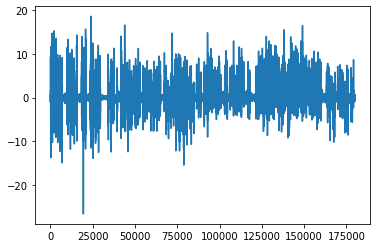

In [5]:
plt.plot(fictrac_data[250]['behave'])
fictrac_data[226]['behave'].shape

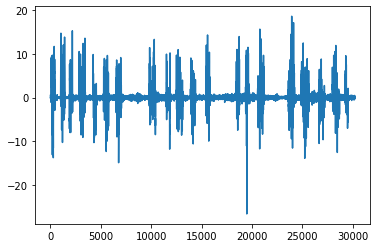

In [6]:
plt.plot(fictrac_data[250]['behave'][:starts_loom[0]])

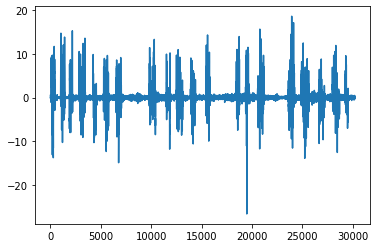

In [7]:
plt.plot(fictrac_data[250]['behave'][:starts_loom[0]])

In [8]:
print(np.max(starts_loom))
print(np.max(stimulus_start_times))
print(np.shape(fictrac_data[250]['behave']))

179610
1796.1034
(180000,)


In [9]:
starts_loom[0]

30208

In [10]:
100*60

6000

In [11]:
(starts_loom[0]-(6000*2))/700

26.01142857142857

In [12]:
print(starts_loom[0])
print(starts_loom[0]-6000)

30208
24208


In [13]:
test=np.arange(6000, (starts_loom[0]-6000),700)
test.shape

(27,)

In [14]:
# 100==1sec, 6000==1min
val_pos=0.1 #10 #
val_neg=-0.1 #-10 #
great_pos=1 #100 #
great_neg=-1 #-100 #
behave_dict={}
behave_pre_post={'inc':[],'dec':[],'flat':[], 'total':[]}
start=300
end=start+400
for fly in fictrac_data:
    fly=str(fly)
    behave_dict[fly]={'inc':[],'dec':[],'flat':[], 'total':[]}
    total_start=6000
    behave=np.asarray(fictrac_data[int(fly)]['behave'])
#     print(np.shape(behave))
    for i in np.arange(total_start, starts_loom[0]-6000,end):
        loom_start=i+start
#         print(loom_start)
        pre=np.mean(behave[(loom_start-50):loom_start])
        post=np.mean(behave[(loom_start+50):(loom_start+100)])
        behave_pre_post['total'].append([pre,post])
        behave_dict[fly]['total'].append(loom_start)
        if pre>val_neg and pre<val_pos and post>val_neg and post<val_pos:
            behave_dict[fly]['flat'].append(loom_start)
            behave_pre_post['flat'].append([pre,post])
#         elif post>np.abs(pre*2):
        elif pre>great_neg and pre <val_pos and post>great_pos and post>np.abs(pre*2):
            behave_dict[fly]['inc'].append(loom_start)
            behave_pre_post['inc'].append([pre,post])
#         elif post<pre/2:
        elif pre>great_pos and post<val_pos and post>great_neg and post<pre/2:
            behave_dict[fly]['dec'].append(loom_start)
            behave_pre_post['dec'].append([pre,post])
    behave_dict[fly]['inc']=np.array(behave_dict[fly]['inc'])
    behave_dict[fly]['dec']=np.array(behave_dict[fly]['dec'])
    behave_dict[fly]['flat']=np.array(behave_dict[fly]['flat'])
    behave_dict[fly]['total']=np.unique(behave_dict[fly]['total'])

In [15]:
for b in behave_pre_post:
    behave_pre_post[b]=np.asarray(behave_pre_post[b])

In [16]:
count_dic={'inc':0,
            'dec':0,
            'flat':0,
            'total':0
          }
for fly in behave_dict:
    for b in behave_dict[fly]:
        count_dic[b]+=len(behave_dict[fly][b])
        
print(f'inc: {count_dic["inc"]}, dec: {count_dic["dec"]}, flat: {count_dic["flat"]}, total: {count_dic["total"]}')

inc: 30, dec: 26, flat: 55, total: 270


In [17]:
behavior_colors={
    'inc': '#FC00B9',
    'dec': '#17D4DE',
    'flat': '#000000',
    'non': '#F5F5F5',
    'total': '#F5F5F5',
    'other': '#F5F5F5'
}

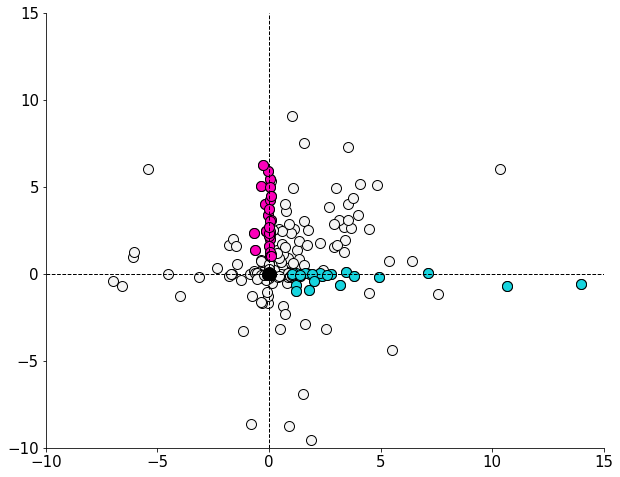

In [18]:
fig,ax=plt.subplots(figsize=(10, 8))
# plt.scatter(total_pre, total_post);
behavior_set=behave_pre_post
order=['total','inc','dec','flat']
for key in order:
#     print(key)
    ax.scatter(np.asarray(behavior_set[key])[:,0], np.asarray(behavior_set[key])[:,1], s=100,color=behavior_colors[key], edgecolor='k', label=key);
ax.spines['top'].set_visible(False);
ax.spines['right'].set_visible(False);
# ax.set_xticklabels([]);
# ax.set_yticklabels([]);
ax.set_xlim(-10,15)
ax.set_ylim(-10,15)
plt.axvline(0,color='k',linestyle='--',lw=1);
plt.axhline(0,color='k',linestyle='--',lw=1);
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
# plt.savefig(os.path.join(save_dir,'ctrl_scatter.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)

In [19]:
behave_dict['226']['inc']

array([ 7000, 10500, 17500, 19600])

In [20]:
avg_be={'inc':[],'dec':[],'flat':[],'total':[]}
for fly in behave_dict:
    for b in behave_dict[fly]:
        arr=behave_dict[fly][b]
        for tp in arr:
            avg_be[b].append(fictrac_data[int(fly)]['behave'][(tp-start):(tp+start+100)])
avg_be['inc']=np.array(avg_be['inc'])
print(f'Inc: {avg_be["inc"].shape}')
avg_be['dec']=np.array(avg_be['dec'])
print(f'Dec: {avg_be["dec"].shape}')
avg_be['flat']=np.array(avg_be['flat'])
print(f'Flat: {avg_be["flat"].shape}')
avg_be['total']=np.array(avg_be['total'])
print(f'Total: {avg_be["total"].shape}')

Inc: (30, 700)
Dec: (26, 700)
Flat: (55, 700)
Total: (270, 700)


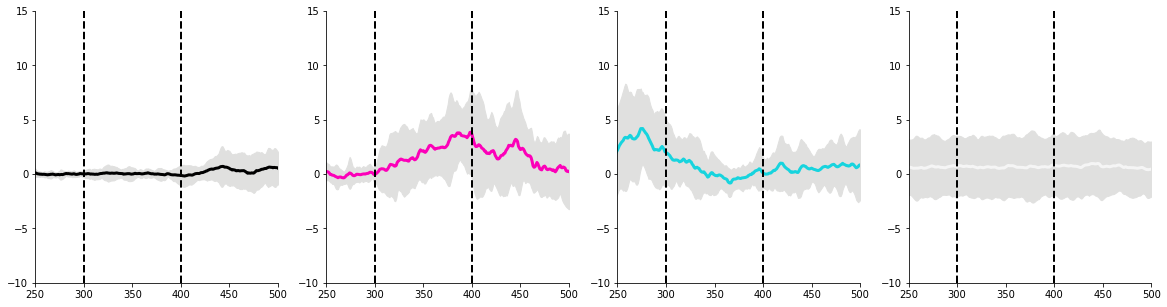

In [21]:
fig,axs=plt.subplots(1,len(list(avg_be.keys())),figsize=(20,5))
order=['flat','inc','dec','total',]
for i,be in enumerate(order):
    mean_trace=np.mean(avg_be[be], axis=0)
    std_trace=np.std(avg_be[be], axis=0)
#     axs[i].plot(avg_be[be].T, color='#e0e0df')
    axs[i].plot(mean_trace, color=behavior_colors[be],lw=3)
    axs[i].fill_between(np.arange(len(mean_trace)),mean_trace-std_trace, mean_trace+std_trace, color='#e0e0df')
    axs[i].axvline((start), linewidth=2, linestyle='--', color='k')
    axs[i].axvline((start+100), linewidth=2, linestyle='--', color='k')
    axs[i].set_ylim(-10, 15);
    axs[i].set_xlim(250, 500);
#     axs[i].set_title(be);
#     axs[i].set_xticklabels([])
#     axs[i].set_yticklabels([])
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
#     if be!='flat':
#         axs[i].spines['left'].set_visible(False)
#         axs[i].set_yticks([])
# plt.savefig(os.path.join(save_dir,'ctrl_traces.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)

In [22]:
print(behave_dict.keys())
print(behave_dict['226'].keys())
print(behave_dict['226']['inc'])

dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])
dict_keys(['inc', 'dec', 'flat', 'total'])
[ 7000 10500 17500 19600]


In [23]:
for fly in behave_dict:
    for be in behave_dict[fly]:
        behave_dict[fly][be]=behave_dict[fly][be]*10

In [24]:
# new_event_name='first_3'
# event_list=behave_dict

# later_path = os.path.join(later_dir, f'{new_event_name}_event_times_split_dic.pkl')

# with open(later_path, 'wb') as file:
#     pickle.dump(event_list, file)

In [25]:
fly_name='226'
be='total'
starts_loom_ms = behave_dict[fly_name][be]
# starts_loom_ms=np.sort(starts_loom_ms)

bin_start = -3000; bin_end = 3000; bin_size = 100 #ms

bins_array=[]
for loom in starts_loom_ms:
#     print(loom)
    start=loom+bin_start
    end=loom+bin_end-bin_size   # why did i subtract out bin size??? 
#     edges=[start,end]
    bins_array.append(start)
    bins_array.append(end)
# bins_test=np.vstack(bins_test)
bins_array=np.array(bins_array)
bins_shape=np.shape(bins_array)

In [26]:
print(behave_dict.keys())
print(behave_dict['226'].keys())
print(behave_dict['226']['total'])

dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])
dict_keys(['inc', 'dec', 'flat', 'total'])
[ 63000  70000  77000  84000  91000  98000 105000 112000 119000 126000
 133000 140000 147000 154000 161000 168000 175000 182000 189000 196000
 203000 210000 217000 224000 231000 238000 245000]


In [27]:
np.diff(bins_array)

array([5900, 1100, 5900, 1100, 5900, 1100, 5900, 1100, 5900, 1100, 5900,
       1100, 5900, 1100, 5900, 1100, 5900, 1100, 5900, 1100, 5900, 1100,
       5900, 1100, 5900, 1100, 5900, 1100, 5900, 1100, 5900, 1100, 5900,
       1100, 5900, 1100, 5900, 1100, 5900, 1100, 5900, 1100, 5900, 1100,
       5900, 1100, 5900, 1100, 5900, 1100, 5900, 1100, 5900])